<a href="https://colab.research.google.com/github/sydas13/ML_Lab_Codes/blob/main/Question6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [184]:
from google.colab import files

In [185]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [186]:
uploaded = files.upload()

Saving telecust.csv to telecust.csv


In [187]:
data = pd.read_csv("telecust.csv")

X = data.drop(columns=["custcat"])
y = data["custcat"]



In [188]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [189]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [190]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)


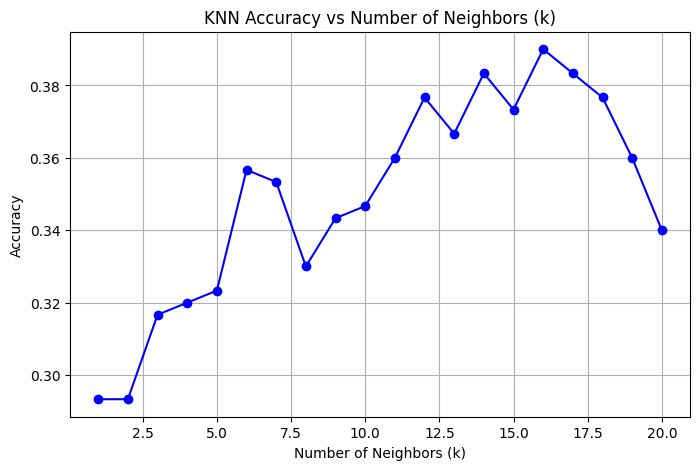

In [191]:

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', color='b')
plt.title('KNN Accuracy vs Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [192]:
best_k = k_values[accuracies.index(max(accuracies))]
print(f"Best K value: {best_k}")
print(f"Best Accuracy: {max(accuracies)*100:.2f}%")

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_best = knn_best.predict(X_test_scaled)


Best K value: 16
Best Accuracy: 39.00%


In [193]:

print(confusion_matrix(y_test, y_pred_best))

print(classification_report(y_test, y_pred_best))

print(f"Final Model Accuracy: {accuracy_score(y_test, y_pred_best)*100:.2f}%")

[[44  7 20 12]
 [17 14 18 16]
 [21 11 42  9]
 [22 15 15 17]]
              precision    recall  f1-score   support

           1       0.42      0.53      0.47        83
           2       0.30      0.22      0.25        65
           3       0.44      0.51      0.47        83
           4       0.31      0.25      0.28        69

    accuracy                           0.39       300
   macro avg       0.37      0.37      0.37       300
weighted avg       0.38      0.39      0.38       300

Final Model Accuracy: 39.00%
